In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Load COT
cot = pd.read_csv('data/cot_clean.csv', parse_dates=['date', 'tradeable_date'])

# Load EOD price data
tickers = {'corn': 'ZS=F', 'soy': 'ZC=F', 'hogs': 'HE=F','live_cattle': 'LE=F','feeder_cattle': 'GF=F'}
eod = {}
for name, ticker in tickers.items():
    df = yf.download(ticker, start='2000-01-01', auto_adjust=True)
    df.columns = ['_'.join(col).strip('_') for col in df.columns]
    eod[name] = df
    print(f"{name}: {len(df)} rows")

[*********************100%***********************]  1 of 1 completed


corn: 6455 rows


[*********************100%***********************]  1 of 1 completed


soy: 6463 rows


[*********************100%***********************]  1 of 1 completed


hogs: 6385 rows


[*********************100%***********************]  1 of 1 completed


live_cattle: 6317 rows


[*********************100%***********************]  1 of 1 completed

feeder_cattle: 6287 rows


In [2]:
cot_market_map = {
    'CORN - CHICAGO BOARD OF TRADE': ('corn', 'ZS=F'),
    'SOYBEANS - CHICAGO BOARD OF TRADE': ('soy', 'ZC=F'),
    'LEAN HOGS - CHICAGO MERCANTILE EXCHANGE': ('hogs', 'HE=F'),
    'LIVE CATTLE - CHICAGO MERCANTILE EXCHANGE': ('live_cattle', 'LE=F'),
    'FEEDER CATTLE - CHICAGO MERCANTILE EXCHANGE': ('feeder_cattle', 'GF=F')
}
#hmm

In [3]:
# =========================================================
# Commercial Position Structure Summary
# =========================================================

structure_rows = []

for cot_name, (short_name, ticker) in cot_market_map.items():
    df = cot[cot["Market and Exchange Names"] == cot_name].copy()

    avg_comm_long = df["Commercial Positions-Long (All)"].mean()
    avg_comm_short = df["Commercial Positions-Short (All)"].mean()
    avg_comm_net = df["comm_net"].mean()
    avg_open_interest = df["Open Interest (All)"].mean()

    avg_comm_share_oi = (
        (df["Commercial Positions-Long (All)"] +
         df["Commercial Positions-Short (All)"]).mean()
        / avg_open_interest
    )

    pct_weeks_net_short = (df["comm_net"] < 0).mean()

    structure_rows.append({
        "Market": short_name,
        "Avg Comm Net": avg_comm_net,
        "Avg Open Interest": avg_open_interest,
        "Commercial Participation Ratio": avg_comm_share_oi,
        "% Weeks Net Short": pct_weeks_net_short
    })

commercial_structure_df = pd.DataFrame(structure_rows)

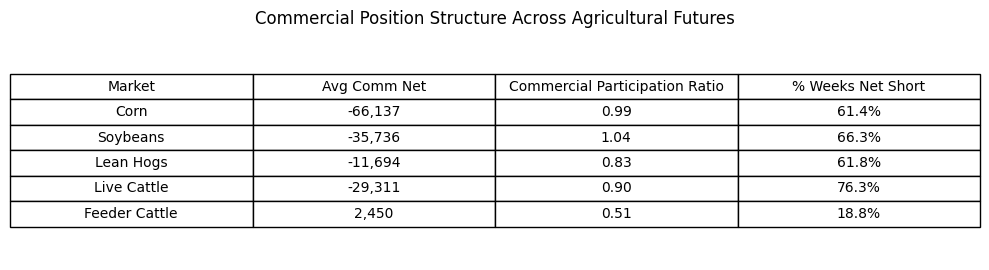

In [4]:
# ---------------------------------
# Select and format display columns
# ---------------------------------

table_df = commercial_structure_df.copy()

display_names = {
    "corn": "Corn",
    "soy": "Soybeans",
    "hogs": "Lean Hogs",
    "live_cattle": "Live Cattle",
    "feeder_cattle": "Feeder Cattle"
}

table_df["Market"] = table_df["Market"].map(display_names)

table_df["Avg Comm Net"] = (
    table_df["Avg Comm Net"]
    .map(lambda x: f"{x:,.0f}")
)

table_df["Commercial Participation Ratio"] = (
    table_df["Commercial Participation Ratio"]
    .map(lambda x: f"{x:.2f}")
)

table_df["% Weeks Net Short"] = (
    table_df["% Weeks Net Short"]
    .map(lambda x: f"{x:.1%}")
)

table_df = table_df[
    [
        "Market",
        "Avg Comm Net",
        "Commercial Participation Ratio",
        "% Weeks Net Short"
    ]
]

# ---------------------------------
# Create matplotlib table
# ---------------------------------

fig, ax = plt.subplots(figsize=(10, 2.8))

ax.axis("off")

table = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.title(
    "Commercial Position Structure Across Agricultural Futures",
    fontsize=12,
    pad=12
)

plt.tight_layout()
plt.show()

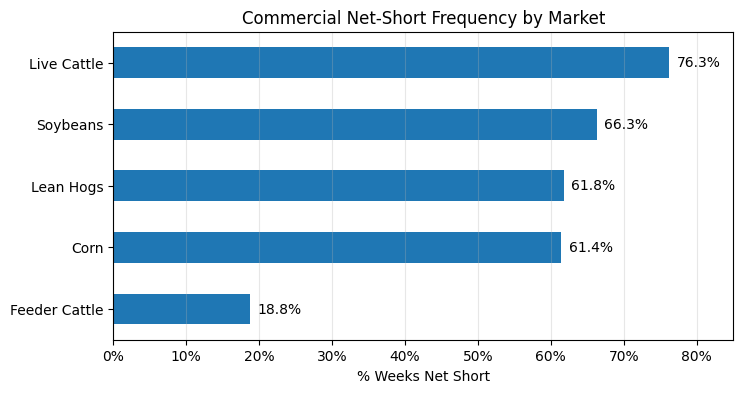

In [5]:
import matplotlib.ticker as mtick

plot_df = commercial_structure_df.copy()

plot_df["Market"] = plot_df["Market"].map(display_names)

plot_df = plot_df.sort_values("% Weeks Net Short", ascending=True)

plot_df.plot(
    x="Market",
    y="% Weeks Net Short",
    kind="barh",
    figsize=(8,4),
    legend=False,
    title="Commercial Net-Short Frequency by Market"
)

plt.xlabel("% Weeks Net Short")
plt.ylabel("")
plt.xlim(0, 0.85)

plt.grid(axis="x", alpha=0.3)

for i, v in enumerate(plot_df["% Weeks Net Short"]):
    plt.text(v + 0.01, i, f"{v:.1%}", va='center')

ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.show()

In [6]:
#Remove, maybe move and change

rows = []

for name, df in eod.items():

    close = df.filter(like="Close").iloc[:,0]
    high  = df.filter(like="High").iloc[:,0]
    low   = df.filter(like="Low").iloc[:,0]

    returns = close.pct_change().dropna()
    ranges = (high - low) / close

    rows.append({
        "market": name,
        "volatility": returns.std(),
        "avg_abs_return": returns.abs().mean(),
        "avg_range": ranges.mean()
    })

table = pd.DataFrame(rows)
print(table.round(4))

          market  volatility  avg_abs_return  avg_range
0           corn      0.0157          0.0110     0.0162
1            soy      0.0178          0.0126     0.0197
2           hogs      0.0233          0.0131     0.0160
3    live_cattle      0.0113          0.0076     0.0103
4  feeder_cattle      0.0105          0.0069     0.0095


In [7]:
merged = {}

for cot_name, (short, ticker) in cot_market_map.items():

    price = eod[short].copy()

    if isinstance(price.columns, pd.MultiIndex):
        price.columns = ['_'.join(col).strip('_') for col in price.columns]

    close_col = next(c for c in price.columns if "Close" in c)
    open_col  = next(c for c in price.columns if "Open" in c)

    price["ret"] = price[close_col].pct_change()
    price["oc_ret"] = (price[close_col] - price[open_col]) / price[open_col]

    cot_mkt = cot[cot["Market and Exchange Names"] == cot_name][
        ["tradeable_date", "cot_idx", "spec_idx", "oi_idx"]
    ].copy()

    price = price.reset_index()
    price["Date"] = price["Date"].astype("datetime64[s]")
    cot_mkt["tradeable_date"] = cot_mkt["tradeable_date"].astype("datetime64[s]")

    merged_df = pd.merge_asof(
        price.sort_values("Date"),
        cot_mkt.sort_values("tradeable_date"),
        left_on="Date",
        right_on="tradeable_date",
        direction="backward"
    ).set_index("Date")

    merged_df = merged_df.dropna(
        subset=["cot_idx", "spec_idx", "oi_idx"]
    )

    merged_df["overnight"] = (
        merged_df["ret"] - merged_df["oc_ret"]
    )

    merged[short] = merged_df

In [8]:
for name in ['corn','soy','hogs','live_cattle','feeder_cattle']:

    d = merged[name].copy()

    d = d[
        d.index >= '2008-01-01'
    ].dropna(
        subset=['cot_idx', 'spec_idx', 'oi_idx']
    )

    d['cot_signal'] = (
        d['cot_idx'] > 0.8
    ).astype(int).shift(1)

    d['cot_spec_signal'] = (
        (d['cot_idx'] > 0.8) &
        (d['spec_idx'] < 0.2)
    ).astype(int).shift(1)

    d['cot_spec_oi_signal'] = (
        (d['cot_idx'] > 0.8) &
        (d['spec_idx'] < 0.2) &
        (d['oi_idx'] > 0.5)
    ).astype(int).shift(1)

    merged[name] = d

In [9]:
def backtest_cot_sized(df, long_thresh=0.8, short_thresh=0.2, long_only=False,
                       target_vol=0.01, vol_window=20, silent=False):

    df = df.copy()

    if "ret" not in df.columns:
        close_col = next(c for c in df.columns if "Close" in c)
        df["ret"] = df[close_col].pct_change()

    df = df.dropna(subset=['cot_idx','ret'])

    df['signal'] = 0
    df.loc[df['cot_idx'] > long_thresh, 'signal'] = 1
    if not long_only:
        df.loc[df['cot_idx'] < short_thresh, 'signal'] = -1

    df['signal'] = df['signal'].shift(1)

    # realized volatility
    df['vol'] = df['ret'].rolling(vol_window).std()

    # avoid divide-by-zero
    df['vol'] = df['vol'].replace(0, np.nan)

    df['size'] = (target_vol / df['vol']).clip(0.1, 3.0)
    df['size'] = df['size'].shift(1)

    df = df.dropna(subset=['size'])

    df['strat_ret'] = df['signal'] * df['size'] * df['ret']
    df['equity'] = (1 + df['strat_ret']).cumprod()

    total_ret = df['equity'].iloc[-1] - 1
    annual_ret = (1 + total_ret) ** (252 / len(df)) - 1

    std = df['strat_ret'].std()
    sharpe = 0 if std == 0 else df['strat_ret'].mean() / std * (252 ** 0.5)

    max_dd = (df['equity'] / df['equity'].cummax() - 1).min()

    trades = df[df['signal'] != 0]['strat_ret']
    win_rate = (trades > 0).mean() if len(trades) else 0
    n_trades = len(trades)

    metrics = dict(
        annual=annual_ret,
        sharpe=sharpe,
        max_dd=max_dd,
        win_rate=win_rate,
        n_days=n_trades
    )

    if not silent:
        for k, v in metrics.items():
            print(f"{k}: {v:.3f}")

    return df, metrics

In [10]:
# need to remake this with the current backtest. 
periods = {
    "2008-2012": ("2008-01-01", "2012-12-31"),
    "2013-2016": ("2013-01-01", "2016-12-31"),
    "2017-2020": ("2017-01-01", "2020-12-31"),
    "2021-2024": ("2021-01-01", "2024-12-31"),
}

market_labels = {
    "corn": "Corn",
    "soy": "Soybeans",
    "hogs": "Lean Hogs",
    "live_cattle": "Live Cattle",
    "feeder_cattle": "Feeder Cattle",
}

for market, label in market_labels.items():
    print(f"\n{label}:")
    print(f"{'Period':<12} {'Annual':>8} {'Sharpe':>8} {'MaxDD':>8} {'WinRate':>8}")

    for period_name, (start, end) in periods.items():
        period_df = merged[market].loc[start:end].copy()
        _, m = backtest_cot_sized(period_df, long_only=True, silent=True)
        print(
            f"{period_name:<12} {m['annual']:>8.2%} {m['sharpe']:>8.3f} "
            f"{m['max_dd']:>8.2%} {m['win_rate']:>8.2%}"
        )


Corn:
Period         Annual   Sharpe    MaxDD  WinRate
2008-2012       5.97%    0.618  -11.74%   55.06%
2013-2016       3.48%    0.376  -16.74%   52.71%
2017-2020       2.62%    0.329  -19.08%   48.41%
2021-2024      -7.10%   -0.651  -26.11%   49.39%

Soybeans:
Period         Annual   Sharpe    MaxDD  WinRate
2008-2012      -1.44%   -0.136  -18.58%   49.22%
2013-2016      -4.92%   -0.353  -32.89%   50.00%
2017-2020       5.45%    0.640   -9.74%   55.65%
2021-2024       0.94%    0.142  -22.59%   46.94%

Lean Hogs:
Period         Annual   Sharpe    MaxDD  WinRate
2008-2012      11.04%    0.657   -8.18%   47.27%
2013-2016       1.87%    0.225  -20.53%   54.58%
2017-2020       0.41%    0.096  -21.71%   47.24%
2021-2024       5.00%    0.387  -21.92%   46.21%

Live Cattle:
Period         Annual   Sharpe    MaxDD  WinRate
2008-2012      -0.22%    0.022  -22.92%   49.71%
2013-2016      -2.22%   -0.214  -21.56%   48.65%
2017-2020      -2.30%   -0.113  -24.66%   50.76%
2021-2024       2.17%    

In [11]:
import pandas as pd
import numpy as np

max_horizon = 60

lower_tail_direction = {
    "corn": "short",
    "soy": "long",
    "hogs": "long",
    "live_cattle": "long",
    "feeder_cattle": "long",
}

rows = []

for market, label in market_labels.items():
    d = merged[market].loc['2008':].copy()
    close_col = next(c for c in d.columns if "Close" in c)

    d['upper_tail'] = (d['cot_idx'] >= 0.8).astype(bool)
    d['lower_tail'] = (d['cot_idx'] <= 0.2).astype(bool)

    prev_upper = d['upper_tail'].shift(1, fill_value=False)
    prev_lower = d['lower_tail'].shift(1, fill_value=False)

    d['upper_entry'] = d['upper_tail'] & (~prev_upper)
    d['lower_entry'] = d['lower_tail'] & (~prev_lower)

    signal_specs = [
        ("upper", "upper_tail", "upper_entry", "long"),
        ("lower", "lower_tail", "lower_entry", lower_tail_direction[market]),
    ]

    for tail_name, tail_col, entry_col, direction in signal_specs:
        entry_locs = np.where(d[entry_col].values)[0]

        durations = []
        mfe_days = []
        mfe_returns = []

        for loc in entry_locs:
            run_len = 0
            j = loc

            while j < len(d) and bool(d[tail_col].iloc[j]):
                run_len += 1
                j += 1

            durations.append(run_len)

            if loc + max_horizon >= len(d):
                continue

            future_prices = d[close_col].iloc[loc:loc + max_horizon + 1]
            rel_path = future_prices / future_prices.iloc[0] - 1

            if direction == "long":
                mfe_idx = rel_path.values.argmax()
            else:
                mfe_idx = rel_path.values.argmin()

            mfe_days.append(int(mfe_idx))
            mfe_returns.append(float(rel_path.iloc[mfe_idx]))

        rows.append({
            "Market": label,
            "Tail": tail_name,
            "Direction": direction,
            "Events": len(entry_locs),
            "Avg Cluster Days": np.mean(durations) if durations else np.nan,
            "Avg Days to Peak Return": np.mean(mfe_days) if mfe_days else np.nan,
            "Avg Peak Return": np.mean(mfe_returns) if mfe_returns else np.nan,
        })

tail_mfe_summary = pd.DataFrame(rows)
tail_mfe_summary.style.format({
    "Events": "{:.0f}",
    "Avg Cluster Days": "{:.1f}",
    "Avg Days to Peak Return": "{:.1f}",
    "Avg Peak Return": "{:.2%}",
})

tail_mfe_summary.style.hide(axis="index")

Market,Tail,Direction,Events,Avg Cluster Days,Avg Days to Peak Return,Avg Peak Return
Corn,upper,long,37,38.648649,30.756757,0.091925
Corn,lower,short,22,46.590909,36.500000,-0.094121
Soybeans,upper,long,37,32.648649,31.378378,0.082899
Soybeans,lower,long,32,37.781250,27.781250,0.119506
Lean Hogs,upper,long,30,34.600000,41.200000,0.198482
Lean Hogs,lower,long,26,43.153846,28.615385,0.138935
Live Cattle,upper,long,38,31.447368,32.710526,0.059079
Live Cattle,lower,long,29,42.724138,42.275862,0.075977
Feeder Cattle,upper,long,37,31.459459,35.405405,0.062322
Feeder Cattle,lower,long,25,45.040000,32.800000,0.070603


Lower-tail signal direction varied across commodities and was assigned empirically based on observed forward-return structure.

In [12]:
import pandas as pd

horizon = 30
rows = []

for market, label in market_labels.items():
    d = merged[market].loc['2008':].copy()

    close_col = next(c for c in d.columns if "Close" in c)
    d['fwd_ret'] = d[close_col].shift(-horizon) / d[close_col] - 1

    tmp = d[['cot_idx', 'fwd_ret']].dropna().copy()
    tmp['bucket'] = pd.qcut(
        tmp['cot_idx'],
        5,
        labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'],
        duplicates='drop'
    )

    summary = (
        tmp.groupby('bucket', observed=False)['fwd_ret']
        .agg(['mean', 'count'])
        .reset_index()
    )
    summary['win_rate'] = (
        tmp.groupby('bucket', observed=False)['fwd_ret']
        .apply(lambda x: (x > 0).mean())
        .values
    )
    summary['market'] = label

    rows.append(summary)

bucket_results = pd.concat(rows, ignore_index=True)
bucket_results
bucket_results.style.hide(axis="index")

bucket,mean,count,win_rate,market
Q1,0.005328,923,0.481040,Corn
Q2,-0.008126,918,0.476035,Corn
Q3,-0.000558,918,0.540305,Corn
Q4,0.012105,916,0.576419,Corn
Q5,0.005347,916,0.544760,Corn
Q1,0.013847,920,0.543478,Soybeans
Q2,0.012009,917,0.534351,Soybeans
Q3,0.000440,917,0.498364,Soybeans
Q4,-0.014909,918,0.460784,Soybeans
Q5,0.011452,917,0.589967,Soybeans


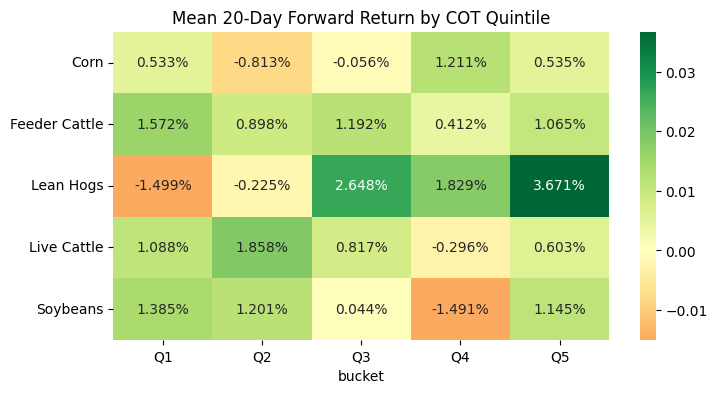

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

heat = bucket_results.pivot(index='market', columns='bucket', values='mean')

plt.figure(figsize=(8, 4))
sns.heatmap(heat, annot=True, fmt=".3%", cmap="RdYlGn", center=0)
plt.title("Mean 20-Day Forward Return by COT Quintile")
plt.ylabel("")
plt.show()


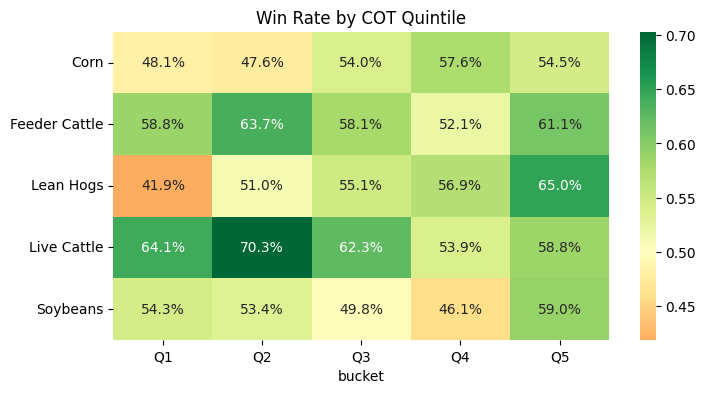

In [14]:
heat_wr = bucket_results.pivot(index='market', columns='bucket', values='win_rate')

plt.figure(figsize=(8, 4))
sns.heatmap(heat_wr, annot=True, fmt=".1%", cmap="RdYlGn", center=0.5)
plt.title("Win Rate by COT Quintile")
plt.ylabel("")
plt.show()



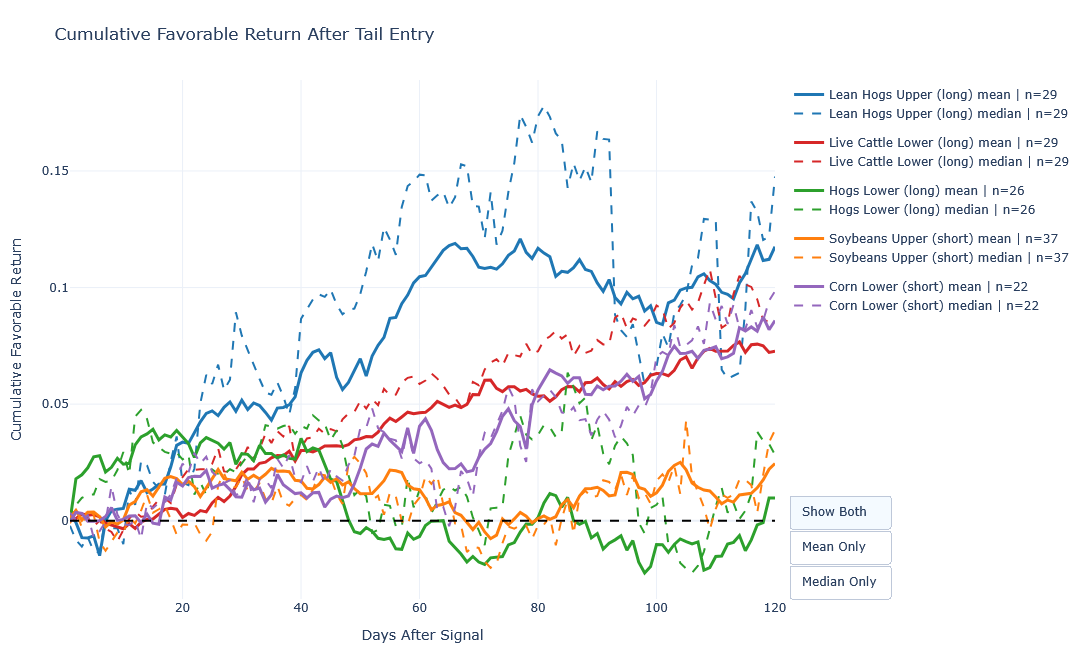

In [15]:
import numpy as np
import plotly.graph_objects as go

max_horizon = 120

signal_specs = [
    ("hogs", "Lean Hogs Upper", "upper", "long"),
    ("live_cattle", "Live Cattle Lower", "lower", "long"),
    ("hogs", "Hogs Lower", "lower", "long"),
    ("soy", "Soybeans Upper", "upper", "short"),
    ("corn", "Corn Lower", "lower", "short"),
]

series_data = []

for market, label, tail, direction in signal_specs:
    d = merged[market].loc["2008":].copy()
    close_col = next(c for c in d.columns if "Close" in c)
    d["ret"] = d[close_col].pct_change()

    if tail == "upper":
        d["tail_state"] = d["cot_idx"] >= 0.8
    else:
        d["tail_state"] = d["cot_idx"] <= 0.2

    prev_state = d["tail_state"].shift(1, fill_value=False)
    d["entry"] = d["tail_state"] & (~prev_state)

    entry_locs = np.where(d["entry"].values)[0]
    paths = []

    for loc in entry_locs:
        if loc + max_horizon >= len(d):
            continue

        future = d["ret"].iloc[loc + 1 : loc + 1 + max_horizon].values
        path = np.cumsum(future)

        if direction == "short":
            path = -path

        paths.append(path)

    if len(paths) == 0:
        continue

    paths = np.array(paths)

    series_data.append({
        "name": f"{label} ({direction})",
        "mean": paths.mean(axis=0),
        "median": np.median(paths, axis=0),
        "n": len(paths),
    })

fig = go.Figure()
x = np.arange(1, max_horizon + 1)

colors = [
    "#1f77b4",
    "#d62728",
    "#2ca02c",
    "#ff7f0e",
    "#9467bd",
    "#8c564b",
]

for i, s in enumerate(series_data):
    color = colors[i % len(colors)]
    group = s["name"]

    fig.add_trace(
        go.Scatter(
            x=x,
            y=s["mean"],
            mode="lines",
            name=f"{s['name']} mean | n={s['n']}",
            legendgroup=group,
            line=dict(color=color, width=3, dash="solid"),
            hovertemplate=(
                "<b>%{fullData.name}</b><br>"
                "Day %{x}<br>"
                "Return %{y:.2%}<extra></extra>"
            ),
            visible=True,
        )
    )

    fig.add_trace(
        go.Scatter(
            x=x,
            y=s["median"],
            mode="lines",
            name=f"{s['name']} median | n={s['n']}",
            legendgroup=group,
            line=dict(color=color, width=2, dash="dash"),
            hovertemplate=(
                "<b>%{fullData.name}</b><br>"
                "Day %{x}<br>"
                "Return %{y:.2%}<extra></extra>"
            ),
            visible=True,
        )
    )

n_signals = len(series_data)
both_visible = [True, True] * n_signals
mean_only = []
median_only = []

for _ in range(n_signals):
    mean_only.extend([True, False])
    median_only.extend([False, True])

fig.update_layout(
    title="Cumulative Favorable Return After Tail Entry",
    xaxis_title="Days After Signal",
    yaxis_title="Cumulative Favorable Return",
    hovermode="x unified",
    template="plotly_white",
    width=1250,
    height=650,
    margin=dict(l=70, r=260, t=80, b=70),
    updatemenus=[
        {
            "type": "buttons",
            "direction": "down",
            "x": 1.02,
            "y": 0.2,
            "xanchor": "left",
            "yanchor": "top",
            "showactive": True,
            "buttons": [
                {
                    "label": "Show Both",
                    "method": "update",
                    "args": [
                        {"visible": both_visible},
                        {"title": "Cumulative Favorable Return After Tail Entry"},
                    ],
                },
                {
                    "label": "Mean Only",
                    "method": "update",
                    "args": [
                        {"visible": mean_only},
                        {"title": "Mean Cumulative Favorable Return After Tail Entry"},
                    ],
                },
                {
                    "label": "Median Only",
                    "method": "update",
                    "args": [
                        {"visible": median_only},
                        {"title": "Median Cumulative Favorable Return After Tail Entry"},
                    ],
                },
            ],
        }
    ],
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1.0,
        xanchor="left",
        x=1.02
    ),
)

fig.add_hline(y=0, line_dash="dash", line_color="black")

fig.show()

In [16]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

signal_specs = [
    {
        "Signal": "Lean Hogs upper long",
        "market": "hogs",
        "tail": "upper",
        "direction": "long",
        "eval_horizon": 60,
    },
    {
        "Signal": "Lean Hogs lower long",
        "market": "hogs",
        "tail": "lower",
        "direction": "long",
        "eval_horizon": 20,
    },
    {
        "Signal": "Live Cattle lower long",
        "market": "live_cattle",
        "tail": "lower",
        "direction": "long",
        "eval_horizon": 90,
    },
    {
        "Signal": "Soy upper short",
        "market": "soy",
        "tail": "upper",
        "direction": "short",
        "eval_horizon": 30,
    },
    {
        "Signal": "Corn lower short",
        "market": "corn",
        "tail": "lower",
        "direction": "short",
        "eval_horizon": 120,
    },
]

entry_rules = [
    ("Day 0",   0),
    ("Day +5",  5),
    ("Day +10", 10),
    ("Day +15", 15),
]

def build_signal_frame(spec):
    d = merged[spec["market"]].loc["2008":].copy()
    close_col = next(c for c in d.columns if "Close" in c)
    if spec["tail"] == "upper":
        d["tail_state"] = (d["cot_idx"] >= 0.8).astype(bool)
    else:
        d["tail_state"] = (d["cot_idx"] <= 0.2).astype(bool)
    prev_state = d["tail_state"].shift(1, fill_value=False)
    d["entry_event"] = d["tail_state"] & (~prev_state)
    return d, close_col

all_results = []

for spec in signal_specs:
    d, close_col = build_signal_frame(spec)
    event_locs = np.where(d["entry_event"].values)[0]
    signal_rows = []

    for entry_label, lag_days in entry_rules:
        trade_returns = []
        trade_mfe     = []
        trade_peak_day = []

        for signal_loc in event_locs:
            entry_loc = signal_loc + lag_days
            exit_loc  = signal_loc + spec["eval_horizon"]

            # need enough room for both entry and exit
            if entry_loc >= len(d) or exit_loc >= len(d):
                continue
            # skip if lag has already consumed the horizon
            if entry_loc >= exit_loc:
                continue

            entry_price = d[close_col].iloc[entry_loc]
            window      = d[close_col].iloc[entry_loc : exit_loc + 1]
            raw_path    = window / entry_price - 1
            fav_path    = raw_path if spec["direction"] == "long" else -raw_path

            trade_returns.append(float(fav_path.iloc[-1]))
            trade_mfe.append(float(fav_path.max()))
            trade_peak_day.append(int(fav_path.values.argmax()))

        signal_rows.append({
            "Entry":        entry_label,
            "Lag Days":     lag_days,
            "Window (days)": spec["eval_horizon"] - lag_days,
            "n Trades":     len(trade_returns),
            "Mean Return":  np.mean(trade_returns)               if trade_returns else np.nan,
            "Median Return":np.median(trade_returns)             if trade_returns else np.nan,
            "Win Rate":     np.mean(np.array(trade_returns) > 0) if trade_returns else np.nan,
            "Avg MFE":      np.mean(trade_mfe)                   if trade_mfe     else np.nan,
            "Avg Peak Day": np.mean(trade_peak_day)              if trade_peak_day else np.nan,
        })

    signal_df = pd.DataFrame(signal_rows).set_index("Entry")

    # format for display
    fmt = {
        "Mean Return":   "{:.2%}",
        "Median Return": "{:.2%}",
        "Win Rate":      "{:.1%}",
        "Avg MFE":       "{:.2%}",
        "Avg Peak Day":  "{:.1f}",
    }
    display(Markdown(f"### {spec['Signal']}  —  horizon: {spec['eval_horizon']}d  |  direction: {spec['direction']}"))
    display(signal_df.style.format(fmt, na_rep="—"))

    all_results.append(signal_df.assign(Signal=spec["Signal"]))
# maybe remove the avg mfe or avg peak day. not sure.

### Lean Hogs upper long  —  horizon: 60d  |  direction: long

,Lag Days,Window (days),n Trades,Mean Return,Median Return,Win Rate,Avg MFE,Avg Peak Day
Entry,,,,,,,,
Day 0,0,60,30,10.99%,14.66%,73.3%,19.85%,41.2
Day +5,5,55,30,11.34%,11.97%,80.0%,20.56%,39.7
Day +10,10,50,30,10.14%,12.11%,76.7%,19.21%,34.9
Day +15,15,45,30,9.59%,13.13%,66.7%,18.41%,31.9


### Lean Hogs lower long  —  horizon: 20d  |  direction: long

,Lag Days,Window (days),n Trades,Mean Return,Median Return,Win Rate,Avg MFE,Avg Peak Day
Entry,,,,,,,,
Day 0,0,20,26,3.72%,2.50%,65.4%,8.65%,11.0
Day +5,5,15,26,0.83%,0.10%,50.0%,5.38%,7.5
Day +10,10,10,26,1.17%,0.53%,50.0%,4.60%,4.7
Day +15,15,5,26,-0.34%,-0.05%,46.2%,1.88%,2.6


### Live Cattle lower long  —  horizon: 90d  |  direction: long

,Lag Days,Window (days),n Trades,Mean Return,Median Return,Win Rate,Avg MFE,Avg Peak Day
Entry,,,,,,,,
Day 0,0,90,29,6.09%,7.27%,72.4%,9.87%,64.6
Day +5,5,85,29,5.80%,8.63%,75.9%,9.39%,60.1
Day +10,10,80,29,6.43%,8.42%,79.3%,9.86%,56.9
Day +15,15,75,29,6.01%,7.51%,79.3%,9.39%,52.0


### Soy upper short  —  horizon: 30d  |  direction: short

,Lag Days,Window (days),n Trades,Mean Return,Median Return,Win Rate,Avg MFE,Avg Peak Day
Entry,,,,,,,,
Day 0,0,30,37,2.08%,2.14%,62.2%,7.23%,17.6
Day +5,5,25,37,1.51%,0.55%,54.1%,6.44%,14.3
Day +10,10,20,37,1.93%,0.40%,51.4%,6.27%,11.3
Day +15,15,15,37,0.99%,0.94%,56.8%,4.96%,7.9


### Corn lower short  —  horizon: 120d  |  direction: short

,Lag Days,Window (days),n Trades,Mean Return,Median Return,Win Rate,Avg MFE,Avg Peak Day
Entry,,,,,,,,
Day 0,0,120,22,8.34%,10.63%,81.8%,16.25%,70.5
Day +5,5,115,22,8.32%,9.22%,77.3%,16.18%,65.8
Day +10,10,110,22,8.02%,8.95%,77.3%,15.78%,61.2
Day +15,15,105,22,7.88%,10.77%,72.7%,15.63%,58.9


In [17]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

selected_lags = {
    "Lean Hogs upper long":   5,
    "Lean Hogs lower long":   0,
    "Live Cattle lower long": 10,
    "Soy upper short":        0,
    "Corn lower short":       0,
}

def rolling_unconditional(d, close_col, horizon, direction):
    closes = d[close_col].values
    returns = []
    for i in range(len(closes) - horizon):
        entry_price = closes[i]
        exit_price  = closes[i + horizon]
        r = exit_price / entry_price - 1
        if direction == "short":
            r = -r
        returns.append(r)
    returns = np.array(returns)
    return {
        "Uncond. Mean":    np.mean(returns),
        "Uncond. Median":  np.median(returns),
        "Uncond. Win Rate": np.mean(returns > 0),
        "Uncond. n":       len(returns),
    }

rows = []

for spec in signal_specs:
    d, close_col = build_signal_frame(spec)
    event_locs   = np.where(d["entry_event"].values)[0]
    lag_days     = selected_lags[spec["Signal"]]

    # --- signal stats at selected lag ---
    trade_returns = []
    for signal_loc in event_locs:
        entry_loc = signal_loc + lag_days
        exit_loc  = signal_loc + spec["eval_horizon"]
        if entry_loc >= len(d) or exit_loc >= len(d):
            continue
        if entry_loc >= exit_loc:
            continue
        entry_price = d[close_col].iloc[entry_loc]
        window      = d[close_col].iloc[entry_loc : exit_loc + 1]
        raw_path    = window / entry_price - 1
        fav_path    = raw_path if spec["direction"] == "long" else -raw_path
        trade_returns.append(float(fav_path.iloc[-1]))

    trade_returns = np.array(trade_returns)

    # --- unconditional benchmark ---
    bench = rolling_unconditional(d, close_col, spec["eval_horizon"], spec["direction"])

    rows.append({
        "Signal":            spec["Signal"],
        "Direction":         spec["direction"],
        "Horizon":           spec["eval_horizon"],
        "Selected Lag":      f"Day +{lag_days}",
        "Signal n":          len(trade_returns),
        "Signal Mean":       np.mean(trade_returns)               if len(trade_returns) else np.nan,
        "Signal Median":     np.median(trade_returns)             if len(trade_returns) else np.nan,
        "Signal Win Rate":   np.mean(trade_returns > 0)           if len(trade_returns) else np.nan,
        "Uncond. n":         bench["Uncond. n"],
        "Uncond. Mean":      bench["Uncond. Mean"],
        "Uncond. Median":    bench["Uncond. Median"],
        "Uncond. Win Rate":  bench["Uncond. Win Rate"],
        "Edge (Mean)":       np.mean(trade_returns) - bench["Uncond. Mean"] if len(trade_returns) else np.nan,
        "Edge (Median)":     np.median(trade_returns) - bench["Uncond. Median"] if len(trade_returns) else np.nan,
    })

comparison_df = pd.DataFrame(rows).set_index("Signal")

fmt = {
    "Signal Mean":      "{:.2%}",
    "Signal Median":    "{:.2%}",
    "Signal Win Rate":  "{:.1%}",
    "Uncond. Mean":     "{:.2%}",
    "Uncond. Median":   "{:.2%}",
    "Uncond. Win Rate": "{:.1%}",
    "Edge (Mean)":      "{:.2%}",
    "Edge (Median)":    "{:.2%}",
}

display(Markdown("## Signal vs. Unconditional Rolling Benchmark"))
display(comparison_df.style.format(fmt, na_rep="—")
        .background_gradient(subset=["Edge (Mean)", "Edge (Median)"], cmap="RdYlGn", axis=0))

## Signal vs. Unconditional Rolling Benchmark

,Direction,Horizon,Selected Lag,Signal n,Signal Mean,Signal Median,Signal Win Rate,Uncond. n,Uncond. Mean,Uncond. Median,Uncond. Win Rate,Edge (Mean),Edge (Median)
Signal,,,,,,,,,,,,,
Lean Hogs upper long,long,60,Day +5,30,11.34%,11.97%,80.0%,4559,2.44%,0.82%,51.5%,8.90%,11.15%
Lean Hogs lower long,long,20,Day +0,26,3.72%,2.50%,65.4%,4599,0.88%,1.01%,54.6%,2.84%,1.49%
Live Cattle lower long,long,90,Day +10,29,6.43%,8.42%,79.3%,4527,2.42%,3.60%,64.2%,4.00%,4.82%
Soy upper short,short,30,Day +0,37,2.08%,2.14%,62.2%,4589,-0.46%,-0.55%,47.2%,2.54%,2.69%
Corn lower short,short,120,Day +0,22,8.34%,10.63%,81.8%,4501,-0.89%,1.26%,52.7%,9.23%,9.37%


## Summary Stats

Signal,n Trades,Max Tranches,Win Rate,Mean Return,Alloc/Tranche,Total PnL,Mean Sized Ret,Cumulative Contribution,Avg Hold (days)
Corn lower short,22,3,77.3%,8.32%,15.0%,0.4112,0.0125,0.2747,115
Lean Hogs upper long,29,3,75.9%,12.60%,15.0%,1.1542,0.0189,0.5480,70
Live Cattle lower long,28,3,82.1%,7.83%,15.0%,0.8529,0.0117,0.3289,110
Lean Hogs lower long,26,1,65.4%,3.72%,15.0%,0.3135,0.0056,0.1449,20
Soy upper short,37,3,62.2%,2.08%,15.0%,0.2130,0.0031,0.1155,30
ALL SIGNALS,142,3,71.8%,6.63%,—,2.9448,0.0099,1.4120,—


## Portfolio Metrics

Metric,Value
Final Wealth,3.9448x
CAGR,7.80%
Sharpe Ratio,0.92
Sortino Ratio,1.13
Calmar Ratio,0.54
Max Drawdown,-14.37%
Expectancy per Trade,6.63%
Overall Win Rate,71.8%


## Daily Mark-to-Market Portfolio Wealth

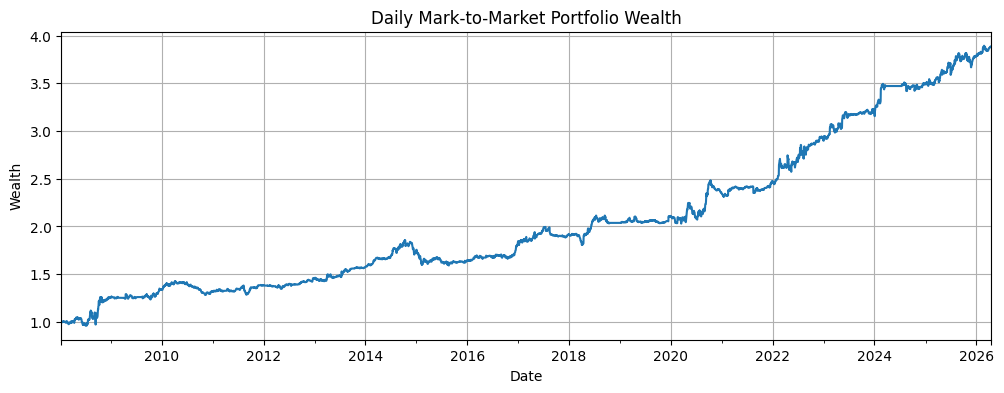

In [18]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, HTML
from IPython.core.display import HTML

display(HTML("<style>div.output_scroll { height: unset; }</style>"))

signal_configs = [
    {
        "Signal":       "Lean Hogs upper long",
        "market":       "hogs",
        "tail":         "upper",
        "direction":    "long",
        "entry_lag":    5,
        "eval_horizon": 75,
    },
    {
        "Signal":       "Lean Hogs lower long",
        "market":       "hogs",
        "tail":         "lower",
        "direction":    "long",
        "entry_lag":    0,
        "eval_horizon": 20,
    },
    {
        "Signal":       "Live Cattle lower long",
        "market":       "live_cattle",
        "tail":         "lower",
        "direction":    "long",
        "entry_lag":    10,
        "eval_horizon": 120,
    },
    {
        "Signal":       "Soy upper short",
        "market":       "soy",
        "tail":         "upper",
        "direction":    "short",
        "entry_lag":    0,
        "eval_horizon": 30,
    },
    {
        "Signal":       "Corn lower short",
        "market":       "corn",
        "tail":         "lower",
        "direction":    "short",
        "entry_lag":    5,
        "eval_horizon": 120,
    },
]

MAX_TRANCHES       = 3
SIGNAL_ALLOCATION  = 0.45
TRANCHE_ALLOCATION = SIGNAL_ALLOCATION / MAX_TRANCHES

def build_signal_frame(cfg):
    d = merged[cfg["market"]].loc["2008":].copy()
    close_col = next(c for c in d.columns if "Close" in c)
    if cfg["tail"] == "upper":
        d["tail_state"] = (d["cot_idx"] >= 0.8).astype(bool)
    else:
        d["tail_state"] = (d["cot_idx"] <= 0.2).astype(bool)
    prev_state = d["tail_state"].shift(1, fill_value=False)
    d["entry_event"] = d["tail_state"] & (~prev_state)
    return d, close_col

all_trades  = []
daily_pnl   = {}
wealth_index   = 1.0
wealth_history = {}

signal_state = {
    cfg["Signal"]: {"open_tranches": []}
    for cfg in signal_configs
}

all_events = []
for cfg in signal_configs:
    d, close_col = build_signal_frame(cfg)
    prices       = d[close_col]
    event_locs   = np.where(d["entry_event"].values)[0]
    for sig_loc in event_locs:
        all_events.append((d.index[sig_loc], sig_loc, cfg, d, close_col, prices))

all_events.sort(key=lambda x: x[0])

for (sig_date, sig_loc, cfg, d, close_col, prices) in all_events:
    direction = cfg["direction"]
    lag       = cfg["entry_lag"]
    horizon   = cfg["eval_horizon"]
    sig_name  = cfg["Signal"]

    entry_loc = sig_loc + lag
    exit_loc  = sig_loc + horizon

    if entry_loc >= len(d) or exit_loc >= len(d):
        continue
    if entry_loc >= exit_loc:
        continue

    state = signal_state[sig_name]
    state["open_tranches"] = [t for t in state["open_tranches"] if t > entry_loc]
    if len(state["open_tranches"]) >= MAX_TRANCHES:
        continue

    state["open_tranches"].append(exit_loc)

    entry_wealth     = wealth_index
    tranche_notional = TRANCHE_ALLOCATION * entry_wealth

    entry_price = prices.iloc[entry_loc]
    exit_price  = prices.iloc[exit_loc]
    ret         = (exit_price / entry_price - 1) * (1 if direction == "long" else -1)

    pnl          = tranche_notional * ret
    wealth_index = wealth_index + pnl
    wealth_history[d.index[exit_loc]] = wealth_index

    sized_ret   = TRANCHE_ALLOCATION * ret

    actual_hold = exit_loc - entry_loc
    for day_offset in range(1, actual_hold + 1):
        day_loc = entry_loc + day_offset
        if day_loc >= len(d):
            break
        day_date   = d.index[day_loc]
        prev_price = prices.iloc[day_loc - 1]
        curr_price = prices.iloc[day_loc]
        daily_ret  = (curr_price / prev_price - 1) * (1 if direction == "long" else -1)
        daily_pnl[day_date] = daily_pnl.get(day_date, 0.0) + TRANCHE_ALLOCATION * daily_ret

    all_trades.append({
        "Signal":       sig_name,
        "Entry Date":   d.index[entry_loc],
        "Exit Date":    d.index[exit_loc],
        "Entry Lag":    lag,
        "Horizon":      actual_hold,
        "Direction":    direction,
        "Entry Price":  entry_price,
        "Exit Price":   exit_price,
        "Raw Return":   ret,
        "Entry Wealth": entry_wealth,
        "Notional":     tranche_notional,
        "PnL":          pnl,
        "Alloc":        TRANCHE_ALLOCATION,
        "Sized Return": sized_ret,
        "Win":          ret > 0,
        "Tranche":      len(state["open_tranches"]),
    })

# ── Trade log ─────────────────────────────────────────────────────────────
trade_df = pd.DataFrame(all_trades).sort_values("Entry Date").reset_index(drop=True)
trade_df["Entry Date"] = pd.to_datetime(trade_df["Entry Date"])
trade_df["Exit Date"]  = pd.to_datetime(trade_df["Exit Date"])

# ── Wealth series (trade-exit compounding) ────────────────────────────────
wealth_series      = pd.Series(wealth_history).sort_index()
wealth_series.name = "Wealth Index"

# ── Daily return series (risk metrics) ───────────────────────────────────
eq_series = pd.Series(daily_pnl).sort_index()
eq_series = eq_series.reindex(
    pd.bdate_range(eq_series.index.min(), eq_series.index.max()), fill_value=0.0
)
wealth_daily      = (1 + eq_series).cumprod()
wealth_daily.name = "Wealth Index (Daily MTM)"

rolling_max = wealth_daily.cummax()
drawdown    = wealth_daily / rolling_max - 1
max_dd      = drawdown.min()

# ── Headline risk metrics ─────────────────────────────────────────────────
ann_factor   = np.sqrt(252)
daily_returns = eq_series.copy()

sharpe = (daily_returns.mean() / daily_returns.std() * ann_factor
          if daily_returns.std() > 0 else np.nan)

downside     = daily_returns[daily_returns < 0]
downside_std = downside.std()
sortino      = (daily_returns.mean() / downside_std * ann_factor
                if downside_std > 0 else np.nan)

years = (wealth_daily.index[-1] - wealth_daily.index[0]).days / 365.25
cagr  = (wealth_index / 1.0) ** (1 / years) - 1  # use final wealth_index directly
calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan

gross_profit_raw = trade_df.loc[trade_df["Raw Return"] > 0, "Raw Return"].sum()
gross_loss_raw   = -trade_df.loc[trade_df["Raw Return"] <= 0, "Raw Return"].sum()
profit_factor    = gross_profit_raw / gross_loss_raw if gross_loss_raw > 0 else np.nan

wins       = trade_df[trade_df["Raw Return"] > 0]["Raw Return"]
losses     = trade_df[trade_df["Raw Return"] <= 0]["Raw Return"]
win_rate   = len(wins) / len(trade_df)
avg_win    = wins.mean()   if len(wins)   > 0 else 0
avg_loss   = -losses.mean() if len(losses) > 0 else 0
expectancy = win_rate * avg_win - (1 - win_rate) * avg_loss

# ── Summary ───────────────────────────────────────────────────────────────
def summarize(df):
    rows = []
    for sig in df["Signal"].unique():
        s = df[df["Signal"] == sig]
        rows.append({
            "Signal":          sig,
            "n Trades":        len(s),
            "Max Tranches":    s["Tranche"].max(),
            "Win Rate":        s["Win"].mean(),
            "Mean Return":     s["Raw Return"].mean(),
            "Alloc/Tranche":   TRANCHE_ALLOCATION,
            "Total PnL":       s["PnL"].sum(),
            "Mean Sized Ret":  s["Sized Return"].mean(),
            "Cumulative Contribution": s["Sized Return"].sum(),
            "Avg Hold (days)": s["Horizon"].mean(),
        })
    total_row = {
        "Signal":          "ALL SIGNALS",
        "n Trades":        len(df),
        "Max Tranches":    df["Tranche"].max(),
        "Win Rate":        df["Win"].mean(),
        "Mean Return":     df["Raw Return"].mean(),
        "Alloc/Tranche":   np.nan,
        "Total PnL":       df["PnL"].sum(),
        "Mean Sized Ret":  df["Sized Return"].mean(),
        "Cumulative Contribution": df["Sized Return"].sum(),
        "Avg Hold (days)": np.nan,
    }
    return pd.concat([pd.DataFrame(rows), pd.DataFrame([total_row])], ignore_index=True)

summary_df = summarize(trade_df)

# ── Display ───────────────────────────────────────────────────────────────
metrics_df = pd.DataFrame({
    "Metric": [
        "Final Wealth",
        "CAGR",
        "Sharpe Ratio",
        "Sortino Ratio",
        "Calmar Ratio",
        "Max Drawdown",
        "Expectancy per Trade",
        "Overall Win Rate",
    ],
    "Value": [
        f"{wealth_index:.4f}x",
        f"{cagr:.2%}",
        f"{sharpe:.2f}",
        f"{sortino:.2f}",
        f"{calmar:.2f}",
        f"{max_dd:.2%}",
        f"{expectancy:.2%}",
        f"{win_rate:.1%}",
    ]
})

display(Markdown("## Summary Stats"))
fmt = {
    "Win Rate":        "{:.1%}",
    "Mean Return":     "{:.2%}",
    "Alloc/Tranche":   "{:.1%}",
    "Total PnL":       "{:.4f}",
    "Mean Sized Ret":  "{:.4f}",
    "Cumulative Contribution": "{:.4f}",
    "Avg Hold (days)": "{:.0f}",
}

display(
    summary_df.style
        .hide(axis="index")
        .format(fmt, na_rep="—")
)

display(Markdown("## Portfolio Metrics"))
display(
    metrics_df.style.hide(axis="index")
)

display(Markdown("## Daily Mark-to-Market Portfolio Wealth"))
_ = wealth_daily.plot(
    title="Daily Mark-to-Market Portfolio Wealth",
    figsize=(12, 4),
    ylabel="Wealth",
    xlabel="Date",
    grid=True,
)

## Exposure & Risk

Metric,Value
Max Gross Exposure,90.00%
Max Net Exposure,75.00%
Max Concurrent Positions,4
,
Worst Single Day,-10.13%
Worst 5-Day Loss,-11.65%
Max DD Duration (days),675
Time Underwater,92.2%


## Signal Overlap Correlation Matrix

,Corn lower short,Lean Hogs upper long,Live Cattle lower long,Lean Hogs lower long,Soy upper short
Corn lower short,1.00,-0.14,-0.14,-0.07,-0.08
Lean Hogs upper long,-0.14,1.00,-0.09,-0.11,-0.05
Live Cattle lower long,-0.14,-0.09,1.00,-0.11,-0.07
Lean Hogs lower long,-0.07,-0.11,-0.11,1.00,-0.05
Soy upper short,-0.08,-0.05,-0.07,-0.05,1.00


## Allocation Stress Test

,Return Scale,CAGR,Max Drawdown,Calmar
0,0.25,1.94%,-3.75%,0.52
1,0.50,3.87%,-7.39%,0.52
2,1.00,7.70%,-14.37%,0.54


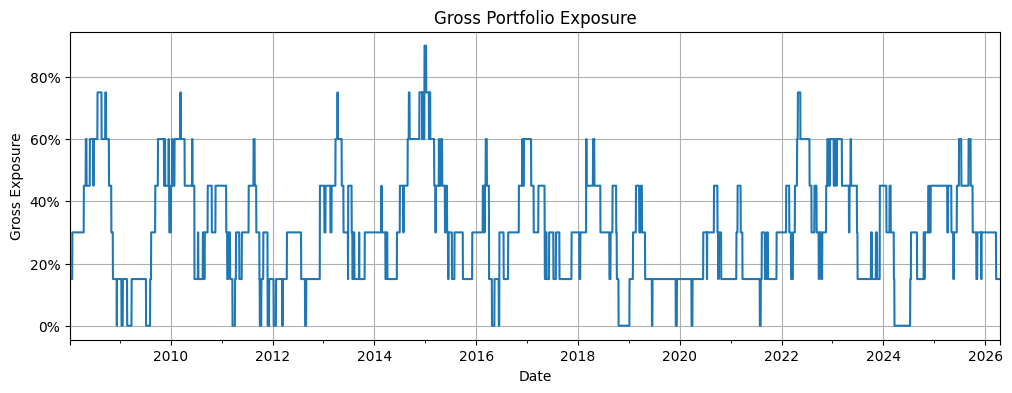

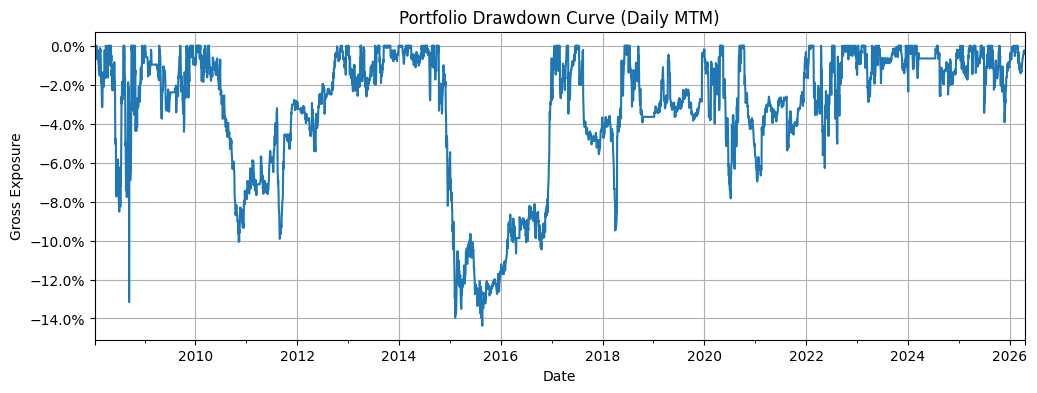

In [19]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, HTML
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

display(HTML("<style>div.output_scroll { height: unset; }</style>"))

# assumes trade_df, eq_series, wealth_daily, wealth_index from backtest cell

# =========================================================
# 0. ASSET MAPPING
# =========================================================
signal_to_asset = {
    "Lean Hogs upper long":   "Lean Hogs",
    "Lean Hogs lower long":   "Lean Hogs",
    "Live Cattle lower long": "Live Cattle",
    "Soy upper short":        "Soy",
    "Corn lower short":       "Corn",
}

trade_df["Asset"] = trade_df["Signal"].map(signal_to_asset)

# guard against unmapped signals
unmapped = trade_df["Asset"].isna().sum()
if unmapped > 0:
    print(f"WARNING: {unmapped} trades have unmapped asset — check signal_to_asset keys")

# =========================================================
# 1. DAILY ACTIVE POSITION MATRIX
# =========================================================
calendar     = pd.bdate_range(trade_df["Entry Date"].min(), trade_df["Exit Date"].max())
signal_names = trade_df["Signal"].unique()
active_matrix = pd.DataFrame(0.0, index=calendar, columns=signal_names)
signed_matrix = pd.DataFrame(0.0, index=calendar, columns=signal_names)

for _, row in trade_df.iterrows():
    days  = pd.bdate_range(row["Entry Date"], row["Exit Date"])
    alloc = row["Alloc"]
    sign  = 1 if row["Direction"] == "long" else -1
    active_matrix.loc[days, row["Signal"]] += abs(alloc)
    signed_matrix.loc[days, row["Signal"]] += sign * alloc

# =========================================================
# 2. ASSET-LEVEL EXPOSURE MATRIX
# =========================================================
valid_trades = trade_df.dropna(subset=["Asset"])
asset_names  = valid_trades["Asset"].unique()
asset_matrix = pd.DataFrame(0.0, index=calendar, columns=asset_names)

for _, row in valid_trades.iterrows():
    days  = pd.bdate_range(row["Entry Date"], row["Exit Date"])
    alloc = abs(row["Alloc"])
    asset_matrix.loc[days, row["Asset"]] += alloc

asset_gross_exposure = asset_matrix.sum(axis=1)

# =========================================================
# 3. EXPOSURE & RISK
# =========================================================
gross_exposure       = active_matrix.sum(axis=1)
net_exposure         = signed_matrix.sum(axis=1)
concurrent_positions = (active_matrix > 0).sum(axis=1)

max_gross_exposure      = gross_exposure.max()
max_net_exposure        = net_exposure.abs().max()
max_concurrent_positions = concurrent_positions.max()

daily_returns = eq_series.copy()
worst_day  = daily_returns.min()
worst_5day = daily_returns.rolling(5).sum().min()

rolling_max = wealth_daily.cummax()
drawdown    = wealth_daily / rolling_max - 1
underwater  = drawdown < 0

dd_durations = []
current_dd   = 0
for val in underwater:
    if val:
        current_dd += 1
    else:
        if current_dd > 0:
            dd_durations.append(current_dd)
        current_dd = 0
if current_dd > 0:
    dd_durations.append(current_dd)

max_dd_duration  = max(dd_durations) if dd_durations else 0
time_under_water = underwater.mean()


display(Markdown("## Exposure & Risk"))
audit_df = pd.DataFrame({
    "Metric": [
        "Max Gross Exposure",
        "Max Net Exposure",
        "Max Concurrent Positions",
        "",
        "Worst Single Day",
        "Worst 5-Day Loss",
        "Max DD Duration (days)",
        "Time Underwater",
    ],
    "Value": [
        f"{max_gross_exposure:.2%}",
        f"{max_net_exposure:.2%}",
        max_concurrent_positions,
        "",
        f"{worst_day:.2%}",
        f"{worst_5day:.2%}",
        f"{max_dd_duration}",
        f"{time_under_water:.1%}",
    ]
})

display(
    audit_df.style.hide(axis="index")
)
# =========================================================
# 6. SIGNAL OVERLAP CORRELATION
# =========================================================
signal_overlap_corr = (active_matrix > 0).astype(int).corr()
display(Markdown("## Signal Overlap Correlation Matrix"))
display(signal_overlap_corr.style.format("{:.2f}").background_gradient(cmap="RdYlGn", axis=None))
# =========================================================
# 8. ALLOCATION STRESS TEST
# =========================================================
stress_results = []
for scale in [0.25, 0.5, 1.0]:
    scaled_daily  = daily_returns * scale
    scaled_wealth = (1 + scaled_daily).cumprod()
    scaled_dd     = scaled_wealth / scaled_wealth.cummax() - 1
    scaled_years  = (scaled_wealth.index[-1] - scaled_wealth.index[0]).days / 365.25
    scaled_cagr   = (scaled_wealth.iloc[-1] / scaled_wealth.iloc[0]) ** (1 / scaled_years) - 1
    scaled_max_dd = scaled_dd.min()
    stress_results.append({
        "Return Scale": scale,
        "CAGR":         f"{scaled_cagr:.2%}",
        "Max Drawdown": f"{scaled_max_dd:.2%}",
        "Calmar":       f"{scaled_cagr / abs(scaled_max_dd):.2f}" if scaled_max_dd < 0 else "—",
    })

display(Markdown("## Allocation Stress Test"))
display(pd.DataFrame(stress_results))

# =========================================================
# PLOTS
# =========================================================
ax = gross_exposure.plot(
    figsize=(12,4),
    title="Gross Portfolio Exposure",
    ylabel="Gross Exposure",
    xlabel="Date",
    grid=True,
)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.show()

bx = drawdown.plot(
    figsize=(12, 4), 
    title="Portfolio Drawdown Curve (Daily MTM)", 
    ylabel = "Gross Exposure",
    xlabel = "Date",
    grid=True,
)
bx.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.show()